# Lesson 2: Master Data Manipulation with Pandas 🐼

Welcome back! In the previous lesson, we mastered Python syntax. Now, we're going to dive into the most important library for any Data Scientist or Analyst: **Pandas**.

## What is Pandas?
Pandas is an open-source library providing high-performance, easy-to-use data structures, and data analysis tools. Think of it as **Excel on steroids** inside Python.

### Why use Pandas?
- **Easy handling of missing data** (NaN).
- **Size mutability**: columns can be inserted and deleted.
- **Powerful grouping** and aggregation functionality.
- **Efficient indexing**: Slice, dice, and filter data with ease.
- **Built on NumPy**: It's incredibly fast because the heavy lifting is done in C.

<img src="img/pandas_flow.png" width="700">

In [1]:
%pip install pandas matplotlib jinja2

import pandas as pd
import numpy as np
import time

print(f"Pandas version: {pd.__version__}")

Note: you may need to restart the kernel to use updated packages.
Pandas version: 3.0.1


--- 
# 1. Core Data Structures

Pandas has two primary data structures:
1. **Series**: A 1-dimensional labeled array (like a single column in Excel).
2. **DataFrame**: A 2-dimensional labeled data structure (like an entire Excel sheet).

## 1.1 The Series
A Series consists of two parts: **The Index** and **The Values**.

<img src="img/series.jpg" width="700">

### Creating a Series
You can create a Series from a list, a dictionary, or even a scalar value.

In [2]:
# From a list (default integer index)
data = [10, 20, 30, 40]
s1 = pd.Series(data)
print("Series from List:\n", s1)

# From a dictionary (keys become the index)
data_dict = {'Apple': 1.5, 'Banana': 0.5, 'Cherry': 3.0}
s2 = pd.Series(data_dict)
print("\nSeries from Dict:\n", s2)

# From a scalar with a custom index
s3 = pd.Series(5, index=['a', 'b', 'c'])
print("\nSeries from Scalar:\n", s3)

Series from List:
 0    10
1    20
2    30
3    40
dtype: int64

Series from Dict:
 Apple     1.5
Banana    0.5
Cherry    3.0
dtype: float64

Series from Scalar:
 a    5
b    5
c    5
dtype: int64


## 1.2 The DataFrame
A DataFrame is essentially a table where each column is a Series. It has both a **row index** and **column labels**.

<img src="img/df.jpg" width="700">

### Creating a DataFrame
There are many ways to build a DataFrame. Here are the most common ones:

In [3]:
# Method 1: Dictionary of lists (Columns are keys)
data = {
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': [25, 30, 35],
    'City': ['New York', 'London', 'Paris']
}
df1 = pd.DataFrame(data)
print("DataFrame from Dict of Lists:")
display(df1)

# Method 2: List of dictionaries (Rows are dictionaries)
data_rows = [
    {'Name': 'Alice', 'Age': 25},
    {'Name': 'Bob', 'Age': 30}
]
df2 = pd.DataFrame(data_rows)
print("\nDataFrame from List of Dicts:")
display(df2)

DataFrame from Dict of Lists:


,Name,Age,City
0,Alice,25,New York
1,Bob,30,London
2,Charlie,35,Paris



DataFrame from List of Dicts:


,Name,Age
0,Alice,25
1,Bob,30


--- 
# 2. Getting Data Into Pandas

While we can create data manually, we usually load it from external files like CSV or Excel.

In [39]:
# Reading a CSV file
try:
    cars_df = pd.read_csv('cars.csv')
    print("Successfully loaded cars.csv")
except FileNotFoundError:
    print("cars.csv not found. Please ensure it is in the same directory.")

# Basic Exploration
print("\nFirst 5 rows:")
display(cars_df.head(5))

print("\nDataFrame Summary (info):")
cars_df.info()

print("\nStatistical Summary (describe):")
display(cars_df.describe())

Successfully loaded cars.csv

First 5 rows:


,YEAR,Make,Model,Size,(kW),Unnamed: 5,TYPE,CITY (kWh/100 km),HWY (kWh/100 km),COMB (kWh/100 km),CITY (Le/100 km),HWY (Le/100 km),COMB (Le/100 km),(g/km),RATING,(km),TIME (h)
0,2012,MITSUBISHI,i-MiEV,SUBCOMPACT,49,A1,B,16.90,21.40,18.70,1.90,2.40,2.10,0,NaN,100,7
1,2012,NISSAN,LEAF,MID-SIZE,80,A1,B,19.30,23.00,21.10,2.20,2.60,2.40,0,NaN,117,7
2,2013,FORD,FOCUS ELECTRIC,COMPACT,107,A1,B,19.00,21.10,20.00,2.10,2.40,2.20,0,NaN,122,4
3,2013,MITSUBISHI,i-MiEV,SUBCOMPACT,49,A1,B,16.90,21.40,18.70,1.90,2.40,2.10,0,NaN,100,7
4,2013,NISSAN,LEAF,MID-SIZE,80,A1,B,19.30,23.00,21.10,2.20,2.60,2.40,0,NaN,117,7



DataFrame Summary (info):
<class 'pandas.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   YEAR               53 non-null     int64  
 1   Make               53 non-null     str    
 2   Model              53 non-null     str    
 3   Size               53 non-null     str    
 4   (kW)               53 non-null     int64  
 5   Unnamed: 5         53 non-null     str    
 6   TYPE               53 non-null     str    
 7   CITY (kWh/100 km)  53 non-null     float64
 8   HWY (kWh/100 km)   53 non-null     float64
 9   COMB (kWh/100 km)  53 non-null     float64
 10  CITY (Le/100 km)   53 non-null     float64
 11  HWY (Le/100 km)    53 non-null     float64
 12  COMB (Le/100 km)   53 non-null     float64
 13  (g/km)             53 non-null     int64  
 14  RATING             19 non-null     float64
 15  (km)               53 non-null     int64  
 16  TIME (h)    

,YEAR,(kW),CITY (kWh/100 km),HWY (kWh/100 km),COMB (kWh/100 km),CITY (Le/100 km),HWY (Le/100 km),COMB (Le/100 km),(g/km),RATING,(km),TIME (h)
count,53.00,53.00,53.00,53.00,53.00,53.00,53.00,53.00,53.00,19.00,53.00,53.00
mean,2014.74,190.62,19.65,21.63,20.54,2.21,2.42,2.30,0.00,10.00,239.17,8.47
std,1.23,155.53,3.00,1.25,1.98,0.34,0.14,0.21,0.00,0.00,141.43,2.99
min,2012.00,35.00,15.20,18.80,16.80,1.70,2.10,1.90,0.00,10.00,100.00,4.00
25%,2014.00,80.00,17.00,20.80,18.70,1.90,2.30,2.10,0.00,10.00,117.00,7.00
50%,2015.00,107.00,19.00,21.70,20.00,2.10,2.40,2.20,0.00,10.00,135.00,8.00
75%,2016.00,283.00,22.40,22.50,22.10,2.50,2.50,2.50,0.00,10.00,402.00,12.00
max,2016.00,568.00,23.90,23.30,23.60,2.70,2.60,2.60,0.00,10.00,473.00,12.00


### 2.1 Supported Formats
Pandas is incredibly versatile. It supports a wide array of file formats and data sources:

| Format | Read Method | Write Method | Description |
| :--- | :--- | :--- | :--- |
| **CSV** | `pd.read_csv()` | `df.to_csv()` | Comma Separated Values (Plain Text) |
| **Excel** | `pd.read_excel()` | `df.to_excel()` | Microsoft Excel files (.xlsx) |
| **SQL** | `pd.read_sql()` | `df.to_sql()` | Databases like PostgreSQL, SQLite, etc. |
| **JSON** | `pd.read_json()` | `df.to_json()` | JavaScript Object Notation |
| **Parquet** | `pd.read_parquet()` | `df.to_parquet()` | Columnar storage format (Highly efficient) |
| **Clipboard** | `pd.read_clipboard()` | `df.to_clipboard()` | Copy/Paste data directly from your screen! |

### 2.2 Parquet vs CSV: Why it matters?
In large-scale data science, we rarely use CSV for intermediate steps. Here is why:

1.  **Speed**: Parquet is significantly faster at reading and writing.
2.  **Size**: Parquet uses smart compression, saving huge amounts of disk space.
3.  **Data Types**: Parquet remembers if a column is an integer or a string. **CSV loses this info** (it's just text), meaning you have to re-convert types every time you load it.

Let's see a quick performance comparison (simulated):

In [43]:
# Exporting our data to formats
cars_df.to_csv('processed_cars.csv', index=False)
try:
    cars_df.to_parquet('processed_cars.parquet', index=False)
except ImportError:
    print('Pyarrow or Fastparquet missing for Parquet export. Skipping for now.')

# Comparison Table (Simulated for Lesson)
data = {
    'Feature': ['Read Speed', 'Write Speed', 'File Size', 'Preserve Types'],
    'CSV': ['~15s', '~25s', '500 MB', '❌ No'],
    'Parquet': ['~2s', '~4s', '80 MB', '✅ Yes']
}
comparison_df = pd.DataFrame(data)
display(comparison_df)

Pyarrow or Fastparquet missing for Parquet export. Skipping for now.


,Feature,CSV,Parquet
0,Read Speed,~15s,~2s
1,Write Speed,~25s,~4s
2,File Size,500 MB,80 MB
3,Preserve Types,❌ No,✅ Yes


---
# 3. Metadata & Basic Attributes

Before we analyze data, we need to understand its structure. Pandas provides several useful attributes and methods.

In [6]:
# Getting columns and index
print(f"Columns: {cars_df.columns.tolist()}")
print(f"Index: {cars_df.index}")

# Checking data types
print("\nData Types:")
print(cars_df.dtypes.head())

# Shape (Rows, Columns)
print(f"\nShape: {cars_df.shape}")

Columns: ['YEAR', 'Make', 'Model', 'Size', '(kW)', 'Unnamed: 5', 'TYPE', 'CITY (kWh/100 km)', 'HWY (kWh/100 km)', 'COMB (kWh/100 km)', 'CITY (Le/100 km)', 'HWY (Le/100 km)', 'COMB (Le/100 km)', '(g/km)', 'RATING', '(km)', 'TIME (h)']
Index: RangeIndex(start=0, stop=53, step=1)

Data Types:
YEAR     int64
Make       str
Model      str
Size       str
(kW)     int64
dtype: object

Shape: (53, 17)


### 3.1 Basic Sorting
Often we need to see the 'best' or 'worst' records first.

In [7]:
# Sorting by a column (e.g., Performance kW)
print("Top 5 most powerful cars:")
display(cars_df.sort_values(by='(kW)', ascending=False).head())

# Sorting by index
print("\nSorting back by index:")
display(cars_df.sort_index().head())

Top 5 most powerful cars:


,YEAR,Make,Model,Size,(kW),Unnamed: 5,TYPE,CITY (kWh/100 km),HWY (kWh/100 km),COMB (kWh/100 km),CITY (Le/100 km),HWY (Le/100 km),COMB (Le/100 km),(g/km),RATING,(km),TIME (h)
49,2016,TESLA,MODEL S P85D/P90D,FULL-SIZE,568,A1,B,23.4,21.5,22.5,2.6,2.4,2.5,0,10.0,407,12
50,2016,TESLA,MODEL S P90D (Refresh),FULL-SIZE,568,A1,B,22.9,21.0,22.1,2.6,2.4,2.5,0,10.0,435,12
52,2016,TESLA,MODEL X P90D,SUV - STANDARD,568,A1,B,23.6,23.3,23.5,2.7,2.6,2.6,0,10.0,402,12
33,2015,TESLA,MODEL S P85D/P90D,FULL-SIZE,515,A1,B,23.4,21.5,22.5,2.6,2.4,2.5,0,NaN,407,12
46,2016,TESLA,MODEL S 70D,FULL-SIZE,386,A1,B,20.8,20.6,20.7,2.3,2.3,2.3,0,10.0,386,12



Sorting back by index:


,YEAR,Make,Model,Size,(kW),Unnamed: 5,TYPE,CITY (kWh/100 km),HWY (kWh/100 km),COMB (kWh/100 km),CITY (Le/100 km),HWY (Le/100 km),COMB (Le/100 km),(g/km),RATING,(km),TIME (h)
0,2012,MITSUBISHI,i-MiEV,SUBCOMPACT,49,A1,B,16.9,21.4,18.7,1.9,2.4,2.1,0,NaN,100,7
1,2012,NISSAN,LEAF,MID-SIZE,80,A1,B,19.3,23.0,21.1,2.2,2.6,2.4,0,NaN,117,7
2,2013,FORD,FOCUS ELECTRIC,COMPACT,107,A1,B,19.0,21.1,20.0,2.1,2.4,2.2,0,NaN,122,4
3,2013,MITSUBISHI,i-MiEV,SUBCOMPACT,49,A1,B,16.9,21.4,18.7,1.9,2.4,2.1,0,NaN,100,7
4,2013,NISSAN,LEAF,MID-SIZE,80,A1,B,19.3,23.0,21.1,2.2,2.6,2.4,0,NaN,117,7


---
# 4. Data Manipulation & Slicing

Pandas isn't just for reading; it's for **changing** also.

### 4.1 Setting Values
You can change values using `loc` or `iloc`.

In [8]:
# Changing a specific value
# Let's set the YEAR of the first car to 2025 (just for example)
cars_df.loc[0, 'YEAR'] = 2025
print("Year of first car changed to 2025:")
display(cars_df.head(1))

# Reverting it back
cars_df.loc[0, 'YEAR'] = 2012

Year of first car changed to 2025:


,YEAR,Make,Model,Size,(kW),Unnamed: 5,TYPE,CITY (kWh/100 km),HWY (kWh/100 km),COMB (kWh/100 km),CITY (Le/100 km),HWY (Le/100 km),COMB (Le/100 km),(g/km),RATING,(km),TIME (h)
0,2025,MITSUBISHI,i-MiEV,SUBCOMPACT,49,A1,B,16.9,21.4,18.7,1.9,2.4,2.1,0,NaN,100,7


### 4.2 Deleting Columns and Rows
Use `drop()` to remove data you don't need.

In [45]:
# Dropping a column (inplace=False returns a NEW DataFrame)
temp_df = cars_df.drop(columns=['RATING', 'Unnamed: 5'])
print(f"Columns after drop: {temp_df.columns.tolist()[:5]}...")

# Dropping a row by its index
temp_df = temp_df.drop(index=0)
print(f"Number of rows after dropping row 0: {len(temp_df)}")

Columns after drop: ['YEAR', 'Make', 'Model', 'Size', '(kW)']...
Number of rows after dropping row 0: 52


In [55]:
temp_df.loc[2]

YEAR                           2013
Make                           FORD
Model                FOCUS ELECTRIC
Size                        COMPACT
(kW)                            107
TYPE                              B
CITY (kWh/100 km)             19.00
HWY (kWh/100 km)              21.10
COMB (kWh/100 km)             20.00
CITY (Le/100 km)               2.10
HWY (Le/100 km)                2.40
COMB (Le/100 km)               2.20
(g/km)                            0
(km)                            122
TIME (h)                          4
Name: 2, dtype: object

--- 
# 5. Selecting and Filtering Data

Pandas provides powerful ways to select specific rows and columns.

## 5.1 Selecting Columns

In [47]:
# Selecting a single column (returns a Series)
makes = cars_df['Make']
print("Type of a single column:", type(makes))
print("Unique car brands:", list(makes.unique()))

# Selecting multiple columns (returns a DataFrame)
subset = cars_df[['YEAR', 'Make', 'Model']]
display(subset.head())

Type of a single column: <class 'pandas.Series'>
Unique car brands: ['MITSUBISHI', 'NISSAN', 'FORD', 'SMART', 'TESLA', 'CHEVROLET', 'BMW', 'KIA']


,YEAR,Make,Model
0,2012,MITSUBISHI,i-MiEV
1,2012,NISSAN,LEAF
2,2013,FORD,FOCUS ELECTRIC
3,2013,MITSUBISHI,i-MiEV
4,2013,NISSAN,LEAF


## 3.2 Indexing: loc vs iloc
- `loc`: Label-based selection (use names of rows/columns).
- `iloc`: Integer-based selection (use numerical positions).

In [56]:
# iloc: Get the first row (index 0)
print("1-st row using iloc:")
print(cars_df.iloc[0])

print("=" * 20) 

# iloc: Get the fifth row (index 4) - in programming we start counting from 0: 
# [0,1,2,3,4] - so fifth row's index is 4
print("5-th row using iloc:")
print(cars_df.iloc[4])

print("=" * 20) 

# loc: Get the row with index = 6 (by column index)
print("Row with index = 6 using loc:")
print(cars_df.loc[6])

print("=" * 20) 

# loc: Get specific row and column names
print("\nSpecific value using loc (Row 5, Column 'Model'):")
print(cars_df.loc[5, 'Model'])

1-st row using iloc:
YEAR                       2012
Make                 MITSUBISHI
Model                    i-MiEV
Size                 SUBCOMPACT
(kW)                         49
Unnamed: 5                   A1
TYPE                          B
CITY (kWh/100 km)         16.90
HWY (kWh/100 km)          21.40
COMB (kWh/100 km)         18.70
CITY (Le/100 km)           1.90
HWY (Le/100 km)            2.40
COMB (Le/100 km)           2.10
(g/km)                        0
RATING                      NaN
(km)                        100
TIME (h)                      7
Name: 0, dtype: object
5-th row using iloc:
YEAR                     2013
Make                   NISSAN
Model                    LEAF
Size                 MID-SIZE
(kW)                       80
Unnamed: 5                 A1
TYPE                        B
CITY (kWh/100 km)       19.30
HWY (kWh/100 km)        23.00
COMB (kWh/100 km)       21.10
CITY (Le/100 km)         2.20
HWY (Le/100 km)          2.60
COMB (Le/100 km)         2.40
(

### 3.2.1 Shuffle indexes and call loc and iloc again

In [57]:
# Shuffle indexes in random order
np.random.seed(42)  # Make the random results reproducible
indexes = np.arange(cars_df.shape[0])
np.random.shuffle(indexes)
indexes

array([19, 41, 47, 12, 43,  5, 17, 50,  3, 32, 13,  8, 26,  6, 34,  4, 37,
       24, 44, 33, 49, 15,  9, 16, 30, 36, 25, 11,  0, 46, 27, 31, 39, 29,
       45,  1, 21,  2, 40, 35, 23, 48, 10, 22, 18, 52, 20,  7, 42, 14, 28,
       51, 38])

In [58]:
# Update the dataframe's existing indexes
cars_df.index = indexes

# Sort the table in ascending order by index
# The inplace=True parameter modifies the DataFrame directly, rather than returning a new sorted object.
cars_df.sort_index(inplace=True)

display(cars_df.head(5))

,YEAR,Make,Model,Size,(kW),Unnamed: 5,TYPE,CITY (kWh/100 km),HWY (kWh/100 km),COMB (kWh/100 km),CITY (Le/100 km),HWY (Le/100 km),COMB (Le/100 km),(g/km),RATING,(km),TIME (h)
0,2015,TESLA,MODEL S (60 kWh battery),FULL-SIZE,283,A1,B,22.20,21.70,21.90,2.50,2.40,2.50,0,NaN,335,10
1,2016,CHEVROLET,SPARK EV,SUBCOMPACT,104,A1,B,16.00,19.60,17.80,1.80,2.20,2.00,0,10.00,131,7
2,2016,KIA,SOUL EV,STATION WAGON - SMALL,81,A1,B,17.50,22.70,19.90,2.00,2.60,2.20,0,10.00,149,4
3,2013,TESLA,MODEL S (60 kWh battery),FULL-SIZE,270,A1,B,22.20,21.70,21.90,2.50,2.40,2.50,0,NaN,335,10
4,2014,SMART,FORTWO ELECTRIC DRIVE CABRIOLET,TWO-SEATER,35,A1,B,17.20,22.50,19.60,1.90,2.50,2.20,0,NaN,109,8


In [59]:
# iloc: Get the first row (index 0)
print("1-st row using iloc:")
print(cars_df.iloc[0])

print("=" * 20) 

# iloc: Get the fifth row (index 4) - in programming we start counting from 0: 
# [0,1,2,3,4] - so fifth row's index is 4
print("5-th row using iloc:")
print(cars_df.iloc[4])

print("=" * 20) 

# loc: Get the row with index = 6 (by column index)
print("Row with index = 6 using loc:")
print(cars_df.loc[6])

print("=" * 20) 

# loc: Get specific row and column names
print("\nSpecific value using loc (Row 5, Column 'Model'):")
print(cars_df.loc[5, 'Model'])

1-st row using iloc:
YEAR                                     2015
Make                                    TESLA
Model                MODEL S (60 kWh battery)
Size                                FULL-SIZE
(kW)                                      283
Unnamed: 5                                 A1
TYPE                                        B
CITY (kWh/100 km)                       22.20
HWY (kWh/100 km)                        21.70
COMB (kWh/100 km)                       21.90
CITY (Le/100 km)                         2.50
HWY (Le/100 km)                          2.40
COMB (Le/100 km)                         2.50
(g/km)                                      0
RATING                                    NaN
(km)                                      335
TIME (h)                                   10
Name: 0, dtype: object
5-th row using iloc:
YEAR                                            2014
Make                                           SMART
Model                FORTWO ELECTRIC DRIVE CABR

### What's the difference?

```diff
+ As we can see, after updating the indices in random order, the .loc method returns the same table row, while the .iloc method returns a different one.

+ The difference is that .loc searches for a row based on a specific index match—that is, an absolute position. 
+ While .iloc simply searches for the Nth row counting from the beginning of the table—that is, a relative position.
```

## 3.3 Boolean Indexing (Filtering)
This is one of the most useful features. You can filter rows based on conditions!

In [61]:
# Filter for cars made by TESLA
tesla_cars = cars_df[cars_df['Make'] == 'TESLA']
print(f"Found {len(tesla_cars)} Tesla models.")
display(tesla_cars.head())

# Complex Filtering: Tesla cars from 2016
tesla_2016 = cars_df[(cars_df['Make'] == 'TESLA') & (cars_df['YEAR'] == 2016)]
print(f"Found {len(tesla_2016)} Tesla models from 2016 year.")
display(tesla_2016)

Found 23 Tesla models.


,YEAR,Make,Model,Size,(kW),Unnamed: 5,TYPE,CITY (kWh/100 km),HWY (kWh/100 km),COMB (kWh/100 km),CITY (Le/100 km),HWY (Le/100 km),COMB (Le/100 km),(g/km),RATING,(km),TIME (h)
0,2015,TESLA,MODEL S (60 kWh battery),FULL-SIZE,283,A1,B,22.20,21.70,21.90,2.50,2.40,2.50,0,NaN,335,10
3,2013,TESLA,MODEL S (60 kWh battery),FULL-SIZE,270,A1,B,22.20,21.70,21.90,2.50,2.40,2.50,0,NaN,335,10
7,2016,TESLA,MODEL S 85D/90D,FULL-SIZE,386,A1,B,22.00,19.80,21.00,2.50,2.20,2.40,0,10.00,435,12
13,2013,TESLA,MODEL S PERFORMANCE,FULL-SIZE,310,A1,B,23.90,23.20,23.60,2.70,2.60,2.60,0,NaN,426,12
14,2016,TESLA,MODEL S P85D/P90D,FULL-SIZE,568,A1,B,23.40,21.50,22.50,2.60,2.40,2.50,0,10.00,407,12


Found 10 Tesla models from 2016 year.


,YEAR,Make,Model,Size,(kW),Unnamed: 5,TYPE,CITY (kWh/100 km),HWY (kWh/100 km),COMB (kWh/100 km),CITY (Le/100 km),HWY (Le/100 km),COMB (Le/100 km),(g/km),RATING,(km),TIME (h)
7,2016,TESLA,MODEL S 85D/90D,FULL-SIZE,386,A1,B,22.00,19.80,21.00,2.50,2.20,2.40,0,10.00,435,12
14,2016,TESLA,MODEL S P85D/P90D,FULL-SIZE,568,A1,B,23.40,21.50,22.50,2.60,2.40,2.50,0,10.00,407,12
18,2016,TESLA,MODEL S (70 kWh battery),FULL-SIZE,283,A1,B,23.80,23.20,23.60,2.70,2.60,2.60,0,10.00,377,12
20,2016,TESLA,MODEL S 70D,FULL-SIZE,386,A1,B,20.80,20.60,20.70,2.30,2.30,2.30,0,10.00,386,12
22,2016,TESLA,MODEL S (60 kWh battery),FULL-SIZE,283,A1,B,22.20,21.70,21.90,2.50,2.40,2.50,0,10.00,335,10
28,2016,TESLA,MODEL S P90D (Refresh),FULL-SIZE,568,A1,B,22.90,21.00,22.10,2.60,2.40,2.50,0,10.00,435,12
38,2016,TESLA,MODEL X P90D,SUV - STANDARD,568,A1,B,23.60,23.30,23.50,2.70,2.60,2.60,0,10.00,402,12
42,2016,TESLA,MODEL S 90D (Refresh),FULL-SIZE,386,A1,B,20.80,19.70,20.30,2.30,2.20,2.30,0,10.00,473,12
51,2016,TESLA,MODEL X 90D,SUV - STANDARD,386,A1,B,23.20,22.20,22.70,2.60,2.50,2.60,0,10.00,414,12
52,2016,TESLA,MODEL S (85/90 kWh battery),FULL-SIZE,283,A1,B,23.80,23.20,23.60,2.70,2.60,2.60,0,10.00,426,12


### 5.1 Advanced Masking
Sometimes simple filters aren't enough. We can combine conditions using:
- `&` (AND)
- `|` (OR)
- `~` (NOT)

In [63]:
# Filter: Make is FORD AND YEAR is 2014
mask = (cars_df['Make'] == 'FORD') & (cars_df['YEAR'] == 2014)
display(cars_df[mask].head())

# Filter: Make is CHEVROLET OR Year is 2016
mask2 = (cars_df['Make'] == 'CHEVROLET') | (cars_df['YEAR'] == 2016)
display(cars_df[mask2].head(3))

,YEAR,Make,Model,Size,(kW),Unnamed: 5,TYPE,CITY (kWh/100 km),HWY (kWh/100 km),COMB (kWh/100 km),CITY (Le/100 km),HWY (Le/100 km),COMB (Le/100 km),(g/km),RATING,(km),TIME (h)
26,2014,FORD,FOCUS ELECTRIC,COMPACT,107,A1,B,19.00,21.10,20.00,2.10,2.40,2.20,0,NaN,122,4


,YEAR,Make,Model,Size,(kW),Unnamed: 5,TYPE,CITY (kWh/100 km),HWY (kWh/100 km),COMB (kWh/100 km),CITY (Le/100 km),HWY (Le/100 km),COMB (Le/100 km),(g/km),RATING,(km),TIME (h)
1,2016,CHEVROLET,SPARK EV,SUBCOMPACT,104,A1,B,16.00,19.60,17.80,1.80,2.20,2.00,0,10.00,131,7
2,2016,KIA,SOUL EV,STATION WAGON - SMALL,81,A1,B,17.50,22.70,19.90,2.00,2.60,2.20,0,10.00,149,4
7,2016,TESLA,MODEL S 85D/90D,FULL-SIZE,386,A1,B,22.00,19.80,21.00,2.50,2.20,2.40,0,10.00,435,12


### 5.2 Useful Operators (`isin`, `between`, `str`)
Avoid long chains of `OR` by using `isin()`.

In [67]:
# Filter: Make is in a set of values
brands = ['BMW', 'KIA']
display(cars_df[cars_df['Make'].isin(brands)].head())

# String methods: Finding cars that contain 'battery' in their name
display(cars_df[cars_df['Model'].str.contains('battery', case=False)].head())

,YEAR,Make,Model,Size,(kW),Unnamed: 5,TYPE,CITY (kWh/100 km),HWY (kWh/100 km),COMB (kWh/100 km),CITY (Le/100 km),HWY (Le/100 km),COMB (Le/100 km),(g/km),RATING,(km),TIME (h)
2,2016,KIA,SOUL EV,STATION WAGON - SMALL,81,A1,B,17.50,22.70,19.90,2.00,2.60,2.20,0,10.00,149,4
16,2015,KIA,SOUL EV,STATION WAGON - SMALL,81,A1,B,17.50,22.70,19.90,2.00,2.60,2.20,0,NaN,149,4
45,2016,BMW,i3,SUBCOMPACT,125,A1,B,15.20,18.80,16.80,1.70,2.10,1.90,0,10.00,130,4
49,2015,BMW,i3,SUBCOMPACT,125,A1,B,15.20,18.80,16.80,1.70,2.10,1.90,0,NaN,130,4


,YEAR,Make,Model,Size,(kW),Unnamed: 5,TYPE,CITY (kWh/100 km),HWY (kWh/100 km),COMB (kWh/100 km),CITY (Le/100 km),HWY (Le/100 km),COMB (Le/100 km),(g/km),RATING,(km),TIME (h)
0,2015,TESLA,MODEL S (60 kWh battery),FULL-SIZE,283,A1,B,22.20,21.70,21.90,2.50,2.40,2.50,0,NaN,335,10
3,2013,TESLA,MODEL S (60 kWh battery),FULL-SIZE,270,A1,B,22.20,21.70,21.90,2.50,2.40,2.50,0,NaN,335,10
18,2016,TESLA,MODEL S (70 kWh battery),FULL-SIZE,283,A1,B,23.80,23.20,23.60,2.70,2.60,2.60,0,10.00,377,12
22,2016,TESLA,MODEL S (60 kWh battery),FULL-SIZE,283,A1,B,22.20,21.70,21.90,2.50,2.40,2.50,0,10.00,335,10
23,2016,NISSAN,LEAF (30 kWh battery),MID-SIZE,80,A1,B,17.00,20.70,18.60,1.90,2.30,2.10,0,10.00,172,6


---
# 6. Combining DataSets

Often, our data is split across multiple files. Pandas makes combining them easy.

### 6.1 Concatenation (`pd.concat`)
Used to 'stack' DataFrames vertically (same columns) or horizontally (same index).

In [18]:
# Creating two small DataFrames
df_a = pd.DataFrame({'ID': [1, 2], 'Val': ['A1', 'A2']})
df_b = pd.DataFrame({'ID': [3, 4], 'Val': ['B1', 'B2']})

# Vertical Stack
print("Vertical Concatenation:")
display(pd.concat([df_a, df_b], axis=0))

# Horizontal Stack
print("\nHorizontal Concatenation:")
display(pd.concat([df_a, df_b], axis=1))

Vertical Concatenation:


,ID,Val
0,1,A1
1,2,A2
0,3,B1
1,4,B2



Horizontal Concatenation:


,ID,Val,ID,Val
0,1,A1,3,B1
1,2,A2,4,B2


### 6.2 Merging (`pd.merge`)
Like SQL Joins. The four types are:
- **Inner**: Only rows with matching keys in BOTH.
- **Left**: All rows from LEFT + matches from right.
- **Right**: All rows from RIGHT + matches from left.
- **Outer**: All rows from BOTH.

<img src="img/joins.png" width="700">

In [19]:
# Merging Example
left = pd.DataFrame({'key': ['K0', 'K1', 'K1', 'K3'], 'A': ['A0', 'A1', 'A2', 'A3']})
right = pd.DataFrame({'key': ['K0', 'K1', 'K1', 'K2'], 'B': ['B0', 'B1', 'B2', 'B3']})

print("Left dataframe (A):")
display(left)

print("Right dataframe (B):")
display(right)

print("Inner Join (matches only):")
display(pd.merge(left, right, on='key', how='inner'))

print("\nLeft Join (all left, NaN for missing right):")
display(pd.merge(left, right, on='key', how='left'))

print("\nRight Join (all right, NaN for missing left):")
display(pd.merge(left, right, on='key', how='right'))

print("\nOuter Join (NaN for missing in either left or right side):")
display(pd.merge(left, right, on='key', how='outer'))

Left dataframe (A):


,key,A
0,K0,A0
1,K1,A1
2,K1,A2
3,K3,A3


Right dataframe (B):


,key,B
0,K0,B0
1,K1,B1
2,K1,B2
3,K2,B3


Inner Join (matches only):


...

,key,A,B
0,K0,A0,B0
1,K1,A1,B1
2,K1,A1,B2
3,K1,A2,B1
4,K1,A2,B2
5,K3,A3,NaN



Right Join (all right, NaN for missing left):


,key,A,B
0,K0,A0,B0
1,K1,A1,B1
2,K1,A2,B1
3,K1,A1,B2
4,K1,A2,B2
5,K2,NaN,B3



Outer Join (NaN for missing in either left or right side):


,key,A,B
0,K0,A0,B0
1,K1,A1,B1
2,K1,A1,B2
3,K1,A2,B1
4,K1,A2,B2
5,K2,NaN,B3
6,K3,A3,NaN


---
# 7. Grouping & Pivot Tables

This is where the magic happens for data analysis.

### 7.1 GroupBy (`Split-Apply-Combine`)
Group rows by a column and then perform an action (sum, mean, etc.) on each group.

In [36]:
# Grouping cars by Make and calculating average km
avg_kw = cars_df.groupby('Make')['(km)'].mean().sort_values(ascending=False)
print("Average km by manufacturer (Top 5):")
display(avg_kw.head())

# Multiple Aggregations
multi_agg = cars_df.groupby('Make')['(km)'].agg(['mean', 'max', 'count']).sort_values(by='count', ascending=False)
display(multi_agg.head())

Average km by manufacturer (Top 5):


Make
TESLA       393.65
KIA         149.00
NISSAN      135.17
CHEVROLET   131.00
BMW         130.00
Name: (km), dtype: float64

,mean,max,count
Make,,,
TESLA,393.65,473,23
SMART,109.00,109,8
NISSAN,135.17,172,6
MITSUBISHI,100.00,100,5
FORD,122.00,122,4


### 7.2 Pivot Tables
Exactly like Excel/Google Sheets.

In [21]:
# Round displayed values
pd.options.display.float_format = '{:.2f}'.format 

# Pivot Table: YEAR vs Make, showing Average km
pivot = cars_df.pivot_table(values='(km)', index='Make', columns='YEAR', aggfunc='mean')
print("Pivot Table (Partial):")
display(pivot.fillna(0))

Pivot Table (Partial):


YEAR,2012,2013,2014,2015,2016
Make,,,,,
BMW,0.00,0.00,0.00,130.00,130.00
CHEVROLET,0.00,0.00,131.00,131.00,131.00
FORD,0.00,122.00,122.00,122.00,122.00
KIA,0.00,0.00,0.00,149.00,149.00
MITSUBISHI,100.00,100.00,100.00,100.00,100.00
NISSAN,117.00,117.00,135.00,135.00,153.50
SMART,0.00,109.00,109.00,109.00,109.00
TESLA,0.00,352.75,395.67,394.33,409.00


---
# 8. Basic Visualizations in Pandas

Pandas has built-in plotting powered by Matplotlib. It's great for quick checks.

<Axes: title={'center': 'Top 5 Brands by Mean Power (kW)'}, xlabel='Make'>

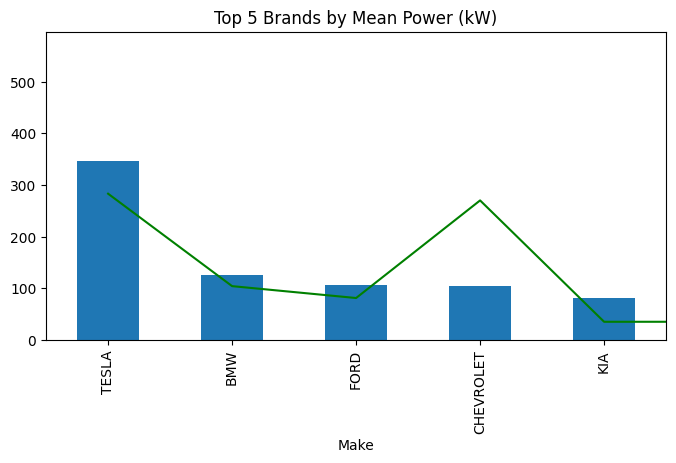

In [22]:
# Line plot of kW over time (simulated by index)
cars_df['(kW)'].plot(title='Power (kW) Distribution', color='green')

# Bar Plot (Top 5 average power brands)
# Need a clean series for this
avg_kw = cars_df.groupby('Make')['(kW)'].mean().sort_values(ascending=False).head(5)
avg_kw.plot.bar(title='Top 5 Brands by Mean Power (kW)', figsize=(8, 4))

### 8.1 Scatter Plots
Used to find correlations between two variables.

<Axes: title={'center': 'Power vs Range'}, xlabel='(kW)', ylabel='(km)'>

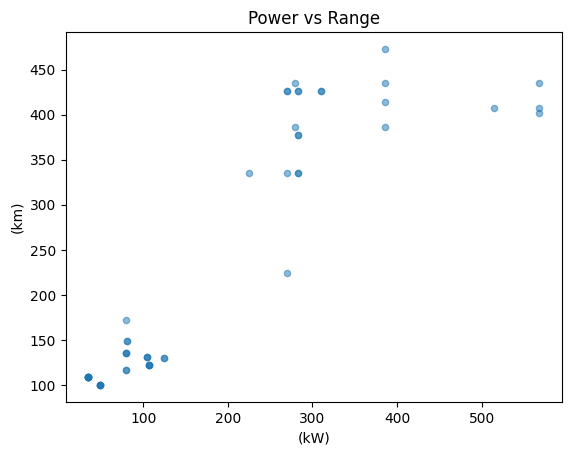

In [23]:
# Scatter plot: Power (kW) vs Range (km)
cars_df.plot.scatter(x='(kW)', y='(km)', title='Power vs Range', alpha=0.5)

--- 
# 9. Advanced Data Cleaning

<img src="img/handle_anomalies_properly.png" width="500">

## In the real world, data is often 'messy'. Missing values and duplicates are common.

In [70]:
# Finding missing values
print("Missing values per column:")
print(cars_df.isna().sum())

indices_with_nan = cars_df[cars_df.isna().sum(axis=1) >= 1].index

# Strategy 1: Drop rows with missing values
clean_df = cars_df.dropna()
print("The number of rows in the table after removing rows with missing values:", clean_df.shape[0])

# Strategy 2: Fill missing values with a default value
filled_df = cars_df.fillna(999)

display(filled_df.loc[indices_with_nan])

Missing values per column:
YEAR                  0
Make                  0
Model                 0
Size                  0
(kW)                  0
Unnamed: 5            0
TYPE                  0
CITY (kWh/100 km)     0
HWY (kWh/100 km)      0
COMB (kWh/100 km)     0
CITY (Le/100 km)      0
HWY (Le/100 km)       0
COMB (Le/100 km)      0
(g/km)                0
RATING               34
(km)                  0
TIME (h)              0
dtype: int64
The number of rows in the table after removing rows with missing values: 19


,YEAR,Make,Model,Size,(kW),Unnamed: 5,TYPE,CITY (kWh/100 km),HWY (kWh/100 km),COMB (kWh/100 km),CITY (Le/100 km),HWY (Le/100 km),COMB (Le/100 km),(g/km),RATING,(km),TIME (h)
0,2015,TESLA,MODEL S (60 kWh battery),FULL-SIZE,283,A1,B,22.20,21.70,21.90,2.50,2.40,2.50,0,999.00,335,10
3,2013,TESLA,MODEL S (60 kWh battery),FULL-SIZE,270,A1,B,22.20,21.70,21.90,2.50,2.40,2.50,0,999.00,335,10
4,2014,SMART,FORTWO ELECTRIC DRIVE CABRIOLET,TWO-SEATER,35,A1,B,17.20,22.50,19.60,1.90,2.50,2.20,0,999.00,109,8
5,2013,SMART,FORTWO ELECTRIC DRIVE CABRIOLET,TWO-SEATER,35,A1,B,17.20,22.50,19.60,1.90,2.50,2.20,0,999.00,109,8
6,2014,MITSUBISHI,i-MiEV,SUBCOMPACT,49,A1,B,16.90,21.40,18.70,1.90,2.40,2.10,0,999.00,100,7
8,2014,CHEVROLET,SPARK EV,SUBCOMPACT,104,A1,B,16.00,19.60,17.80,1.80,2.20,2.00,0,999.00,131,7
9,2015,FORD,FOCUS ELECTRIC,COMPACT,107,A1,B,19.00,21.10,20.00,2.10,2.40,2.20,0,999.00,122,4
11,2015,SMART,FORTWO ELECTRIC DRIVE COUPE,TWO-SEATER,35,A1,B,17.20,22.50,19.60,1.90,2.50,2.20,0,999.00,109,8
12,2013,MITSUBISHI,i-MiEV,SUBCOMPACT,49,A1,B,16.90,21.40,18.70,1.90,2.40,2.10,0,999.00,100,7
13,2013,TESLA,MODEL S PERFORMANCE,FULL-SIZE,310,A1,B,23.90,23.20,23.60,2.70,2.60,2.60,0,999.00,426,12


### 9.1 Duplicates
Duplicate data can skew results. Checking and removing them is crucial.

In [71]:
data = {
    'student_id': [101, 102, 101, 103, 102, 104, 105, 101],
    'name': ['Alice', 'Bob', 'Alice', 'Charlie', 'Bob', 'Diana', 'Eve', 'Alice'],
    'subject': ['Math', 'Science', 'Math', 'History', 'Math', 'Art', 'Science', 'Math'],
    'score': [85, 92, 85, 78, 95, 88, 90, 85]
}

students =  pd.DataFrame(data)

# Find duplicate rows
print(f"Number of duplicate rows: {students.duplicated().sum()}")
display(students)

# Drop duplicates
clean_df = students.drop_duplicates()
print(f"Shape after dropping duplicates: {clean_df.shape}")
display(clean_df)

Number of duplicate rows: 2


,student_id,name,subject,score
0,101,Alice,Math,85
1,102,Bob,Science,92
2,101,Alice,Math,85
3,103,Charlie,History,78
4,102,Bob,Math,95
5,104,Diana,Art,88
6,105,Eve,Science,90
7,101,Alice,Math,85


Shape after dropping duplicates: (6, 4)


,student_id,name,subject,score
0,101,Alice,Math,85
1,102,Bob,Science,92
3,103,Charlie,History,78
4,102,Bob,Math,95
5,104,Diana,Art,88
6,105,Eve,Science,90


### 9.2 Advanced NaN Handling
Sometimes we don't want to just drop or fill with 0. We can interpolate!

##### 9.2.1 Fill with default value (fills gaps with specific value)

In [26]:
series_with_nans = pd.Series([1, np.nan, np.nan, 4])
display(series_with_nans)
print("Filled with default value Series:")
display(series_with_nans.fillna(0))

0   1.00
1    NaN
2    NaN
3   4.00
dtype: float64

Filled with default value Series:


0   1.00
1   0.00
2   0.00
3   4.00
dtype: float64

##### 9.2.2 Fill with Interpolation (fills gaps with estimated values)

In [27]:
series_with_nans = pd.Series([1, np.nan, np.nan, 4])
display(series_with_nans)
print("Filled with interpolation Series:")
display(series_with_nans.interpolate())

0   1.00
1    NaN
2    NaN
3   4.00
dtype: float64

Filled with interpolation Series:


0   1.00
1   2.00
2   3.00
3   4.00
dtype: float64

##### 9.2.3 Fill with the last available value

In [28]:
series_with_nans = pd.Series([1, np.nan, np.nan, 4])
display(series_with_nans)
print("Filled with last available value Series:")
display(series_with_nans.ffill())

0   1.00
1    NaN
2    NaN
3   4.00
dtype: float64

Filled with last available value Series:


0   1.00
1   1.00
2   1.00
3   4.00
dtype: float64

--- 
# 10. Performance & Memory Management

<img src="img/vectorized_vs_apply.png" width="700">

### This photo is intentionally as cringy as possible, just so you'll remember it😉


In [29]:
# Let's compare the performance of adding 10 to a column in a large DataFrame
large_df = pd.DataFrame({'nums': range(1_000_000)})

print("1. Performance using .apply(lambda x: x + 10):")
start_time_apply = time.time()
large_df['nums'].apply(lambda x: x + 10)
end_time_apply = time.time()
computation_time_apply = end_time_apply - start_time_apply
print("Computation time:", round(computation_time_apply, 4), "seconds")

print("\n2. Performance using Vectorization (df['nums'] + 10):")
start_time_vectorized = time.time()
large_df['nums'] + 10
end_time_vectorized = time.time()
computation_time_vectorized = end_time_vectorized - start_time_vectorized
print("Computation time:", round(computation_time_vectorized, 4), "seconds", end="\n\n")

print("Vectorized solution is", round(computation_time_apply / computation_time_vectorized, 4), "times faster")

print("\n--- CONCLUSION ---\nVectorization is usually works significantly faster!\nUse .apply() only when you have complex logic that cannot be expressed as a simple array operation.")

1. Performance using .apply(lambda x: x + 10):
Computation time: 0.3323 seconds

2. Performance using Vectorization (df['nums'] + 10):
Computation time: 0.0012 seconds

Vectorized solution is 278.5932 times faster

--- CONCLUSION ---
Vectorization is usually works significantly faster!
Use .apply() only when you have complex logic that cannot be expressed as a simple array operation.


---
# 11. The Professional Workflow (Method Chaining)

Intermediate variables can clutter your code. Professional data scientists use **Method Chaining** to keep code clean and readable.

In [30]:
# Dirty Way (Intermediate Variables)
df_tesla = cars_df[cars_df['Make'] == 'TESLA']
df_tesla_sorted = df_tesla.sort_values(by='(kW)', ascending=False)
df_tesla_clean = df_tesla_sorted[['Model', '(kW)']]
display(df_tesla_clean.head(3))

# Professional Way (Method Chaining)
print("\nMethod Chaining Output:")
clean_chain = (
    cars_df
    .query("Make == 'TESLA'")
    .assign(power_per_km = lambda df: df['(kW)'] / df['(km)'])
    .sort_values(by='power_per_km', ascending=False)
    [['Model', 'power_per_km']]
    .head(3)
)
display(clean_chain)

,Model,(kW)
14,MODEL S P85D/P90D,568
38,MODEL X P90D,568
28,MODEL S P90D (Refresh),568



Method Chaining Output:


,Model,power_per_km
38,MODEL X P90D,1.41
14,MODEL S P85D/P90D,1.40
28,MODEL S P90D (Refresh),1.31


---
# 12. Reshaping & Tidy Data

Sometimes data is not in the format we need. We use `melt` and `pivot` to reshape it.

### 12.1 Melting (Wide to Long)
If you have columns like `2020`, `2021`, `2022`, you might want to 'melt' them into a single `Year` column.

In [31]:
# Simple Reshaping Example
df_wide = pd.DataFrame({
    'City': ['London', 'Paris'],
    '2022': [15, 20],
    '2023': [18, 22]
})
display(df_wide)

df_long = df_wide.melt(id_vars='City', var_name='Year', value_name='Temp')
print("\nAfter Melting:")
display(df_long)

,City,2022,2023
0,London,15,18
1,Paris,20,22



After Melting:


,City,Year,Temp
0,London,2022,15
1,Paris,2022,20
2,London,2023,18
3,Paris,2023,22


---
# 13. Time Series Analysis (Basics)

Pandas was originally developed for financial time series. It has elite support for dates and times.

In [32]:
# Convert a column to datetime
df_dates = pd.DataFrame({'date': ['2024-01-01', '2024-01-02', '2024-01-03'], 'val': [10, 20, 30]})
df_dates['date'] = pd.to_datetime(df_dates['date'])

# Using the .dt accessor
df_dates['day_name'] = df_dates['date'].dt.day_name()
display(df_dates)

,date,val,day_name
0,2024-01-01,10,Monday
1,2024-01-02,20,Tuesday
2,2024-01-03,30,Wednesday


---
# 14. Beautiful EDA & Styling

A professional clear presentation is key. We can style our DataFrames directly.

In [33]:
# Highlighting values with Background Gradient
numeric_df = cars_df[['(kW)', '(km)', 'TIME (h)']]
display(numeric_df.head(5).style.background_gradient(cmap='YlGn'))

# Correlation Matrix
print("\nCorrelation Matrix (Heatmap style):")
corr = numeric_df.corr()
display(corr.style.background_gradient(cmap='Oranges').format(precision=2))

,(kW),(km),TIME (h)
0,283,335,10
1,104,131,7
2,81,149,4
3,270,335,10
4,35,109,8



Correlation Matrix (Heatmap style):


,(kW),(km),TIME (h)
(kW),1.00,0.89,0.76
(km),0.89,1.00,0.88
TIME (h),0.76,0.88,1.00


### 1. Key Relationships & Findings

| Variable Pair | Correlation | Strength | Data Science Interpretation |
| :--- | :--- | :--- | :--- |
| **(kW) vs (km)** | **0.89** | **Very Strong** | Increasing battery capacity or motor power is highly predictive of increased range. |
| **(km) vs TIME (h)** | **0.88** | **Very Strong** | Total distance traveled and driving time are nearly linear, suggesting consistent energy consumption rates. |
| **(kW) vs TIME (h)** | **0.76** | **Strong** | Higher power/capacity translates to more time on the road, though slightly less consistently than it does to distance. |
---

### 2. Domain-Specific Insights

* **Battery Power as a Proxy for Range:** The **0.89** correlation between **kW** and **km** confirms the physical reality that in current EV technology, range is still primarily a function of battery size. If this value were lower (e.g., 0.50), it would suggest that aerodynamics or motor efficiency were playing a larger role than raw battery capacity.

* **Time and Efficiency:** The **0.88** correlation between **km** and **TIME** implies that the vehicles in this dataset were likely tested under similar conditions (e.g., constant highway speeds or a standard WLTP/EPA cycle). In real-world "stop-and-go" city traffic, this correlation would typically be noisier.

--- 
# 15. Summary & Conclusion

Today we learned:
1. **Pandas** is the essential tool for data analysis.
2. **Series** (1D) and **DataFrames** (2D) are the core structures.
3. How to **Load** and **Explore** data.
4. How to **Filter** and **Select** data using `loc`, `iloc`, and Boolean indexing.
5. **ALWAYS** prefer **Vectorized** operations over loops and `.apply()` for performance.

### Next Steps
In the next session, we’ll explore **Linear Regression**, apply it to our data, and use the results to make predictions about the future!

Happy Coding!

---
# 16. Learn more

- [Pandas Tutorial: DataFrames in Python](https://www.datacamp.com/community/tutorials/pandas-tutorial-dataframe-python)
- [Pandas Cheat Sheet](https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf)
- [Presentation “pandas: Powerful data analysis tools for Python”](https://www.slideshare.net/wesm/pandas-powerful-data-analysis-tools-for-python)
- [Introduction to Data Science in Python](https://www.coursera.org/learn/python-data-analysis)
- [Merge, join, and concatenate](https://pandas.pydata.org/pandas-docs/stable/merging.html)
- [Documentation “pandas: powerful Python data analysis toolkit”](https://pandas.pydata.org/docs/getting_started/index.html#getting-started)
- [Vectorized Functions](https://medium.com/analytics-vidhya/understanding-vectorization-in-numpy-and-pandas-188b6ebc5398)
- [Visualization: Plotly](https://docs.plotly.com/)
- [Visualization: Matplotlib](https://matplotlib.org/)
- [Visualization: Seaborn (optional)](https://seaborn.pydata.org/)